## POV: How can I build a signal with code and analyze it with GNURadio

In [119]:
# ==========================================
# IMPORTS
# ==========================================

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Part 1: Build the Quantum System

We first define the qubit and the resonator.

The qubit has two basis states:

|0⟩ and |1⟩

The resonator has multiple photon-number states.

In [120]:
# ==========================================
# QUBIT STATES
# ==========================================

ground = qt.basis(2, 0)
excited = qt.basis(2, 1)

print("|0⟩:")
print(ground)

print()

print("|1⟩:")
print(excited)

|0⟩:
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]

|1⟩:
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]


In [121]:
# ==========================================
# RESONATOR
# ==========================================

N = 10

resonator = qt.destroy(N) # operator that removes one photon at a time (annihilation operator)

print("Number of resonator states:", N)
print("Resonator operator dimensions:", resonator.dims)

Number of resonator states: 10
Resonator operator dimensions: [[10], [10]]


## Qubit + Resonator State

The complete system is a tensor product:

|ψ⟩ = |qubit⟩ ⊗ |resonator⟩

We start with:

|0⟩ ⊗ |0⟩

meaning:

- qubit starts in the ground state
- resonator starts with zero photons

In [122]:
# ==========================================
# JOINT QUBIT + RESONATOR SYSTEM
# ==========================================

psi0 = qt.tensor(
    ground,         # from the qubit
    qt.basis(N, 0) # from the resonator: N = total size, 0 = state we're choosing
)

print("Initial joint state:")
print(psi0)

print()
print("Joint-state dimensions:", psi0.dims)

Initial joint state:
Quantum object: dims=[[2, 10], [1]], shape=(20, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]

Joint-state dimensions: [[2, 10], [1]]


# Part 2: Build the Qubit-Resonator Hamiltonian

The Hamiltonian describes the energy and interactions
inside the system.

We include:

- qubit energy
- resonator energy
- qubit-resonator coupling
- microwave driving

In [123]:
# ==========================================
# JOINT-SYSTEM OPERATORS
# ==========================================

sm = qt.destroy(2) # 2 = two level system = aka qubit
sz = qt.sigmaz()    # apply Z gate (known 2 level system aka affect only qubit)

sm_joint = qt.tensor(sm, qt.qeye(N)) # annihilate qubit, qeye = 
                                     # leave alone n level system (aka resonator)

sz_joint = qt.tensor(sz, qt.qeye(N)) # apply z gate on qubit, leave alone resonator

a_joint = qt.tensor(qt.qeye(2), resonator) # leave qubit alone, annihilation operator to resonator

print("Operators created.")

Operators created.


In [124]:
# ==========================================
# SYSTEM PARAMETERS
# ==========================================

wq = 5.0       # qubit frequency
wr = 5.0       # resonator frequency
g = 0.1        # qubit-resonator coupling

print("Qubit frequency:", wq)
print("Resonator frequency:", wr)
print("Coupling strength:", g)

Qubit frequency: 5.0
Resonator frequency: 5.0
Coupling strength: 0.1


$$
H =
\hbar\omega_q\,\sigma_+\sigma_-
+
\hbar\omega_r\,a^\dagger a
+
\hbar g
\left(
\sigma_+a+\sigma_-a^\dagger
\right)
$$

$$
\underbrace{\hbar\omega_q\,\sigma_+\sigma_-}_{\text{Qubit Energy}}
+
\underbrace{\hbar\omega_r\,a^\dagger a}_{\text{Resonator Energy}}
+
\underbrace{\hbar g(\sigma_+a+\sigma_-a^\dagger)}_{\text{Qubit--Resonator Coupling}}
$$

$$
\sigma_+ = \text{qubit raising operator}, \qquad
\sigma_- = \text{qubit lowering operator}
$$

$$
a^\dagger = \text{resonator photon creation operator}, \qquad
a = \text{resonator photon annihilation operator}
$$

$$
g = \text{qubit--resonator coupling strength}
$$

In [125]:
# ==========================================
# HAMILTONIAN
# ==========================================

H0 = (
    0.5 * wq * sz_joint
    + wr * a_joint.dag() * a_joint
    + g * (
        sm_joint.dag() * a_joint
        + sm_joint * a_joint.dag()
    )
)

print("Hamiltonian created.")

Hamiltonian created.


# Part 3: Add Microwave Driving

The resonator is driven by a microwave signal.

The drive allows us to probe the resonator.

This is the beginning of the measurement process.

In [126]:
# ==========================================
# MICROWAVE DRIVE
# ==========================================

resonator_drive = (a_joint + a_joint.dag())

drive_amplitude = 0.5
drive_frequency = wr

H_drive = drive_amplitude * resonator_drive

H = [
    H0,
    [
        H_drive,
        lambda t, **kwargs:
        np.cos(drive_frequency * t)
    ]
]

t = np.linspace(0, 100, 1000)

print("Time-dependent Hamiltonian ready.")
print("Number of time points:", len(t))

Time-dependent Hamiltonian ready.
Number of time points: 1000


# Part 4: Add Dissipation

Real quantum systems are not perfectly isolated.

We include:

- T1: qubit energy relaxation
- T2: qubit dephasing
- κ: resonator energy decay

In [127]:
# ==========================================
# DISSIPATION
# ==========================================

T1 = 40.0 # how fast qubit loses its energy - goes from |1> to |0>
T2 = 30.0 # how fast the qubit loses its state - when all the phase errors add too much
kappa = 0.05 # how fast energy leaks out of the resonator

gamma1 = 1.0 / T1 # relaxation rate
gamma_phi = 1.0 / T2 # decoherence rate

c_ops = [ # list of ways my system can destabilize
    np.sqrt(gamma1) * sm_joint,         # qubit can lose energy
    np.sqrt(gamma_phi / 2) * sz_joint,  # qubit can lose coherence
    np.sqrt(kappa) * a_joint            # qubit can lose photons
]

print("T1:", T1)
print("T2:", T2)
print("Resonator decay κ:", kappa)

T1: 40.0
T2: 30.0
Resonator decay κ: 0.05


# Part 5: Run the Quantum Simulation

In [128]:
# ==========================================
# RUN SIMULATION
# ==========================================

result = qt.mesolve( # evolve our quantum state
    H,               # evolution equation including the qubit, resonator, coupling, and drive
    psi0,            # starting curit + resonator state
    t,               # time points we want to simulate
    c_ops=c_ops      # loss / decoherence instructions we just completed
)

print("Simulation complete.")
print("Number of quantum states:", len(result.states))

Simulation complete.
Number of quantum states: 1000


In [129]:
# ==========================================
# QUBIT EXCITED-STATE PROBABILITY
# ==========================================

P_excited = []

for state in result.states:

    rho_qubit = state.ptrace(0) # choose the qubit probability from our density matrix, not resonator

    P1 = qt.expect(excited * excited.dag(), rho_qubit) # expectation value (average result of proabilities for our qubit)

    P_excited.append(P1)

print("Initial P(|1>):", P_excited[0])
print("Maximum P(|1>):", max(P_excited))

Initial P(|1>): 0.0
Maximum P(|1>): 0.0035974610584628293


In [130]:
# ==========================================
# RESONATOR PHOTON NUMBER
# ==========================================

P_resonator = []

for state in result.states:

    n = qt.expect(a_joint.dag() * a_joint, state) # expected number of photons

    P_resonator.append(n)

print(
    "Maximum resonator photon number:",
    max(P_resonator)
)

Maximum resonator photon number: 7.1548950869127665


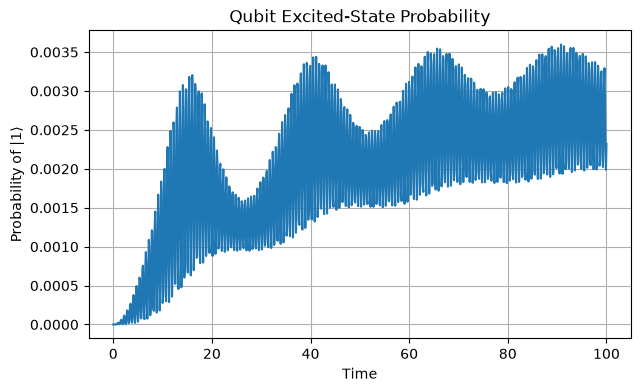

In [131]:
# ==========================================
# PLOT QUBIT DYNAMICS
# ==========================================

plt.figure(figsize=(7, 4))

plt.plot(t, P_excited)

plt.xlabel("Time")
plt.ylabel("Probability of |1⟩")
plt.title("Qubit Excited-State Probability")

plt.grid()
plt.show()

In [132]:
# ==========================================
# DISPERSIVE READOUT PARAMETERS
# ==========================================

n_joint = a_joint.dag() * a_joint

kappa = 0.5
chi = 0.15
drive = 0.4
delta = 0.0

print("κ =", kappa)
print("χ =", chi)
print("Drive =", drive)
print("Detuning =", delta)

κ = 0.5
χ = 0.15
Drive = 0.4
Detuning = 0.0


## Readout of |0⟩

We calculate the steady-state resonator response when
the qubit is in |0⟩.

The complex quantity:

α = ⟨resonator⟩

represents the resonator's complex response.

Its real part corresponds to I.

Its imaginary part corresponds to Q.

In [133]:
H = (
    delta * n_joint
    + chi * n_joint
    + drive * (
        a_joint + a_joint.dag()
    )
)

rho_ground = qt.steadystate(H, c_ops=c_ops)

alpha_ground = qt.expect(a_joint, rho_ground)

print("Readout amplitude for |0⟩:")
print(alpha_ground)

Readout amplitude for |0⟩:
(-1.7500829411078227-0.29168049018463743j)


## Readout of |1⟩

When the qubit is in |1⟩, the resonator experiences
a different effective frequency.

We therefore calculate a second steady-state response.
$$
H_{\text{excited}}
=
\underbrace{\Delta n_{\text{joint}}}_{\text{detuning}}
-
\underbrace{\chi n_{\text{joint}}}_{\text{dispersive shift}}
+
\underbrace{\text{drive}
\left(
a_{\text{joint}}+a_{\text{joint}}^\dagger
\right)}_{\text{microwave drive}}
$$
$$
n_{\text{joint}}
=
a_{\text{joint}}^\dagger a_{\text{joint}}
$$
$$
\Delta n_{\text{joint}}
\quad\rightarrow\quad
\text{detuning between the drive and resonator}
$$
$$
-\chi n_{\text{joint}}
\quad\rightarrow\quad
\text{qubit-induced shift of the resonator}
$$
$$
\text{drive}
\left(a_{\text{joint}}+a_{\text{joint}}^\dagger\right)
\quad\rightarrow\quad
\text{microwave signal driving the resonator}
$$

In [134]:
# ==========================================
# |1⟩ READOUT
# ==========================================

H_excited = (
    delta * n_joint
    - chi * n_joint
    + drive * (
        a_joint + a_joint.dag()
    )
)

rho_excited = qt.steadystate(
    H_excited,
    c_ops=c_ops
)

alpha_excited = qt.expect(
    a_joint,
    rho_excited
)

print("Readout amplitude for |1⟩:")
print(alpha_excited)

Readout amplitude for |1⟩:
(1.7500829411078227-0.29168049018463743j)


Distance formula
$$
\boxed{
d =
\left|
\alpha_{\text{ground}}
-
\alpha_{\text{excited}}
\right|
}
$$
$$
\alpha_{\text{ground}}
=
\text{resonator response when the qubit is in } |0\rangle
$$

$$
\alpha_{\text{excited}}
=
\text{resonator response when the qubit is in } |1\rangle
$$

$$
d
=
\text{distance between the two readout states}
$$
$$
d \text{ large}
\quad\rightarrow\quad
\text{states are easier to distinguish}
$$

$$
d \text{ small}
\quad\rightarrow\quad
\text{states are harder to distinguish}
$$

In [135]:
# ==========================================
# READOUT SEPARATION
# ==========================================

distance = abs(
    alpha_ground - alpha_excited
)

print("Readout amplitude |0⟩:", alpha_ground)
print("Readout amplitude |1⟩:", alpha_excited)
print("Distance between readout states:", distance)

Readout amplitude |0⟩: (-1.7500829411078227-0.29168049018463743j)
Readout amplitude |1⟩: (1.7500829411078227-0.29168049018463743j)
Distance between readout states: 3.5001658822156454


# Part 7: Generate Noisy I/Q Measurements

A real measurement contains noise.

For every measurement shot we generate:

I = Re(α) + noise

Q = Im(α) + noise

We randomly prepare either |0⟩ or |1⟩ for each shot.

We will generate 1,000 measurements.

In [136]:
# ==========================================
# GENERATE READOUT SHOTS
# ==========================================

num_shots = 1000
noise_level = 0.5

labels = np.random.randint(
    0,
    2,
    num_shots
)

I = np.zeros(num_shots)
Q = np.zeros(num_shots)

for i in range(num_shots):

    if labels[i] == 0:
        signal = alpha_ground
    else:
        signal = alpha_excited

    I[i] = (
        signal.real
        + noise_level * np.random.randn()
    )

    Q[i] = (
        signal.imag
        + noise_level * np.random.randn()
    )

IQ = I + 1j * Q

print("Number of shots:", num_shots)
print("Noise level:", noise_level)

Number of shots: 1000
Noise level: 0.5


In [137]:
# ==========================================
# SAVE DATA
# ==========================================

dataset = np.column_stack( # column I, column Q, column label with all labels as 0 or 1 based on I and Q
    (I, Q, labels)
)

np.savetxt(
    "readout_shots_IQ.csv", # make human - easy - to - read file
    dataset,
    delimiter=",", # a comma separates the columns in the CSV file
    header="I,Q,label",
    comments=""
)

IQ_float32 = np.column_stack(
    (I, Q)
).astype(np.float32)

IQ_float32.tofile( # make binary file - directly useful for GNURadio for our file source (instead of borrowing a signal source from them)
    "readout_shots_IQ_float32.bin"
)

print("Saved readout_shots_IQ.csv")
print("Saved readout_shots_IQ_float32.bin")

Saved readout_shots_IQ.csv
Saved readout_shots_IQ_float32.bin


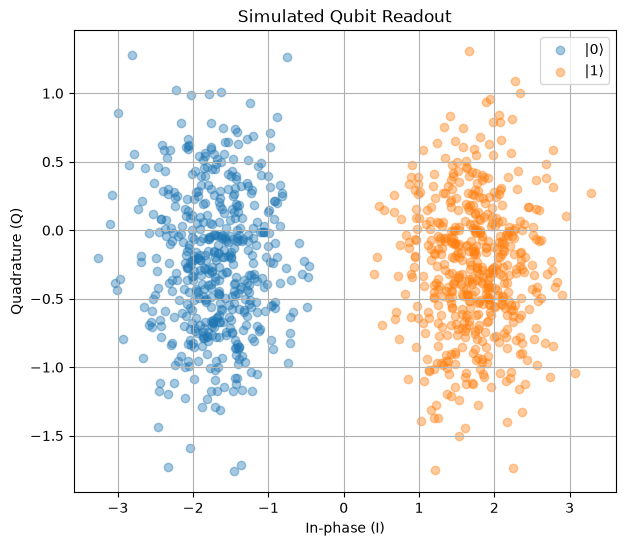

In [138]:
# ==========================================
# I/Q READOUT CLOUD
# ==========================================

plt.figure(figsize=(7, 6))

plt.scatter(
    I[labels == 0],
    Q[labels == 0],
    alpha=0.4,
    label="|0⟩"
)

plt.scatter(
    I[labels == 1],
    Q[labels == 1],
    alpha=0.4,
    label="|1⟩"
)

plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")

plt.title("Simulated Qubit Readout")

plt.legend()
plt.grid()

plt.show()